# 问题三：影响因素分析（优化版）

## 目标
分析专业舞者和名人特征（年龄、行业等）对比赛表现的影响。

## 核心任务
1. 识别影响比赛表现的关键因素
2. 量化各因素的影响程度
3. 比较因素对评委打分 vs 观众投票的影响差异

## 优化内容
- **交互效应分析**: 年龄×行业交互项
- **Pro Dancer能力整合**: 使用爬取的专业舞者历史战绩数据
- **Pageviews整合**: 使用Wikipedia浏览量作为名人关注度代理变量

In [29]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.model_selection import cross_val_score
import warnings
warnings.filterwarnings('ignore')

plt.rcParams['font.sans-serif'] = ['Arial Unicode MS', 'SimHei', 'DejaVu Sans']
plt.rcParams['axes.unicode_minus'] = False
sns.set_theme(style='whitegrid')

FIGSIZE_NORMAL = (10, 6)
FIGSIZE_WIDE = (12, 6)
COLORS = {
    'primary': '#4682B4',
    'secondary': '#FF7F50',
    'accent': '#228B22',
    'neutral': '#708090'
}

np.random.seed(42)

In [30]:
# 读取数据
df = pd.read_csv('../数据预处理/data_processed.csv')
vote_estimates = pd.read_csv('../问题一/vote_estimates.csv')

print(f'选手数据: {len(df)} 行')
print(f'投票估算: {len(vote_estimates)} 行')
print(f'\n可用特征:')
print(df.columns.tolist())

选手数据: 421 行
投票估算: 2777 行

可用特征:
['celebrity_name', 'ballroom_partner', 'celebrity_industry', 'celebrity_homestate', 'celebrity_homecountry/region', 'celebrity_age_during_season', 'season', 'results', 'placement', 'week1_judge1_score', 'week1_judge2_score', 'week1_judge3_score', 'week1_judge4_score', 'week2_judge1_score', 'week2_judge2_score', 'week2_judge3_score', 'week2_judge4_score', 'week3_judge1_score', 'week3_judge2_score', 'week3_judge3_score', 'week3_judge4_score', 'week4_judge1_score', 'week4_judge2_score', 'week4_judge3_score', 'week4_judge4_score', 'week5_judge1_score', 'week5_judge2_score', 'week5_judge3_score', 'week5_judge4_score', 'week6_judge1_score', 'week6_judge2_score', 'week6_judge3_score', 'week6_judge4_score', 'week7_judge1_score', 'week7_judge2_score', 'week7_judge3_score', 'week7_judge4_score', 'week8_judge1_score', 'week8_judge2_score', 'week8_judge3_score', 'week8_judge4_score', 'week9_judge1_score', 'week9_judge2_score', 'week9_judge3_score', 'week9_judge4_sco

## 第一部分：特征工程

识别可用于分析的特征：
1. **名人特征**: celebrity_age, celebrity_industry, celebrity_homestate
2. **专业舞者**: pro_dancer + 历史战绩（wins, top3_finishes, avg_placement）
3. **赛季特征**: season, voting_method
4. **外部数据**: Wikipedia Pageviews（名人关注度）

### 1.1 加载补充数据

In [31]:
# 加载补充数据
# 1. Pro Dancer 历史战绩
pro_dancer_stats = pd.read_csv('../额外补充数据集/external_outputs/pro_dancer_stats.csv')
print(f'专业舞者统计: {len(pro_dancer_stats)} 位')
print(f'Pro Dancer 统计列: {pro_dancer_stats.columns.tolist()}')

# 2. Wikipedia Pageviews（S21-S34）
try:
    pageviews_df = pd.read_csv('../额外补充数据集/external_outputs/pageviews_s21_s34.csv')
    print(f'Pageviews数据: {len(pageviews_df)} 位选手')
    HAS_PAGEVIEWS = True
except:
    print('Pageviews数据不可用')
    HAS_PAGEVIEWS = False

# 显示Pro Dancer统计摘要
print('\n' + '='*60)
print('【Pro Dancer历史战绩 Top 5】')
print('='*60)
print(pro_dancer_stats.head().to_string(index=False))

专业舞者统计: 60 位
Pro Dancer 统计列: ['pro_dancer', 'seasons_participated', 'total_partners', 'wins', 'top3_finishes', 'avg_placement', 'avg_score', 'first_season', 'last_season', 'career_span']
Pageviews数据: 183 位选手

【Pro Dancer历史战绩 Top 5】
           pro_dancer  seasons_participated  total_partners  wins  top3_finishes  avg_placement  avg_score  first_season  last_season  career_span
          Derek Hough                    17              17     6              9           2.94       8.88             5           23           19
          Mark Ballas                    21              20     3             10           5.19       8.31             5           34           30
Valentin Chmerkovskiy                    19              19     3              9           5.26       8.37            13           32           20
         Cheryl Burke                    25              24     2              8           5.80       7.65             2           31           30
       Julianne Hough            

In [32]:
# 准备分析数据 - 使用正确的列名
# 合并选手基本信息到投票估算数据
contestant_info = df[['celebrity_name', 'season', 'celebrity_age_during_season', 'celebrity_industry', 
                       'celebrity_homestate', 'ballroom_partner', 'final_rank', 'is_finalist',
                       'overall_avg_score', 'active_weeks']].copy()
# 重命名列以便后续使用
contestant_info = contestant_info.rename(columns={
    'celebrity_name': 'contestant',
    'celebrity_age_during_season': 'celebrity_age',
    'ballroom_partner': 'pro_dancer'
})

# 计算每位选手的平均投票和评分
contestant_votes = vote_estimates.groupby(['contestant', 'season']).agg({
    'estimated_vote_prop': 'mean',
    'total_score': 'mean'
}).reset_index()
contestant_votes.columns = ['contestant', 'season', 'avg_vote_prop', 'avg_score']

# 合并基础数据
analysis_df = contestant_info.merge(contestant_votes, on=['contestant', 'season'], how='left')
analysis_df = analysis_df.dropna(subset=['avg_vote_prop', 'avg_score'])

# 【优化1】整合Pro Dancer历史战绩
analysis_df = analysis_df.merge(
    pro_dancer_stats[['pro_dancer', 'wins', 'top3_finishes', 'avg_placement', 'seasons_participated']],
    on='pro_dancer',
    how='left'
)
# 填充缺失值（新舞者）
analysis_df['wins'] = analysis_df['wins'].fillna(0)
analysis_df['top3_finishes'] = analysis_df['top3_finishes'].fillna(0)
analysis_df['avg_placement'] = analysis_df['avg_placement'].fillna(10)
analysis_df['seasons_participated'] = analysis_df['seasons_participated'].fillna(1)

# 【优化2】整合Pageviews（S21-S34）
if HAS_PAGEVIEWS:
    analysis_df = analysis_df.merge(
        pageviews_df[['celebrity_name', 'season', 'total_pageviews', 'avg_daily_pageviews']].rename(
            columns={'celebrity_name': 'contestant'}
        ),
        on=['contestant', 'season'],
        how='left'
    )
    analysis_df['log_pageviews'] = np.log1p(analysis_df['total_pageviews'].fillna(0))
    print(f'Pageviews覆盖: {analysis_df["total_pageviews"].notna().sum()}/{len(analysis_df)}')

print(f'分析数据: {len(analysis_df)} 位选手')
print(f'新增特征: wins, top3_finishes, avg_placement, seasons_participated')
analysis_df.head()

Pageviews覆盖: 183/421
分析数据: 421 位选手
新增特征: wins, top3_finishes, avg_placement, seasons_participated


,contestant,season,celebrity_age,celebrity_industry,celebrity_homestate,pro_dancer,final_rank,is_finalist,overall_avg_score,active_weeks,avg_vote_prop,avg_score,wins,top3_finishes,avg_placement,seasons_participated,total_pageviews,avg_daily_pageviews,log_pageviews
0,John O'Hurley,1,50,Actor/Actress,Maine,Charlotte Jorgensen,2.0,True,8.055556,6,0.305746,24.166667,0,1,2.00,1,NaN,NaN,0.0
1,Kelly Monaco,1,29,Actor/Actress,Pennsylvania,Alec Mazo,1.0,True,7.111111,6,0.251279,21.333333,1,1,8.40,5,NaN,NaN,0.0
2,Evander Holyfield,1,42,Athlete,Alabama,Edyta Sliwinska,NaN,False,5.000000,3,0.182030,15.000000,0,2,7.55,11,NaN,NaN,0.0
3,Rachel Hunter,1,35,Model,Non-US,Jonathan Roberts,NaN,False,7.916667,4,0.197062,23.750000,0,1,8.71,7,NaN,NaN,0.0
4,Joey McIntyre,1,32,Singer/Rapper,Massachusetts,Ashly DelGrosso,3.0,True,7.033333,5,0.203103,21.100000,0,1,7.25,4,NaN,NaN,0.0


In [33]:
# 特征编码
# 行业编码
industry_dummies = pd.get_dummies(analysis_df['celebrity_industry'], prefix='industry')

# 地区编码（简化：是否美国本土）
analysis_df['is_us'] = (analysis_df['celebrity_homestate'] != 'Non-US').astype(int)

# 专业舞者编码
pro_dancer_encoder = LabelEncoder()
analysis_df['pro_dancer_encoded'] = pro_dancer_encoder.fit_transform(analysis_df['pro_dancer'].fillna('Unknown'))

# 【优化3】创建交互效应特征（年龄×行业）
# 选择主要行业进行交互
main_industries = ['Athlete', 'Actor/Actress', 'Singer/Rapper', 'TV Personality']
for ind in main_industries:
    col_name = f'age_x_{ind.replace("/", "_").replace(" ", "_")}'
    is_ind = (analysis_df['celebrity_industry'] == ind).astype(int)
    analysis_df[col_name] = analysis_df['celebrity_age'] * is_ind

# 合并特征
features_df = pd.concat([analysis_df.reset_index(drop=True), industry_dummies.reset_index(drop=True)], axis=1)

print('行业分布:')
print(analysis_df['celebrity_industry'].value_counts())
print('\n新增交互效应特征:')
print([c for c in analysis_df.columns if c.startswith('age_x_')])

行业分布:
celebrity_industry
Actor/Actress               128
Athlete                      95
TV Personality               67
Singer/Rapper                61
Model                        17
Comedian                     12
Social Media Personality      8
Entrepreneur                  4
Radio Personality             4
Racing Driver                 4
Politician                    3
News Anchor                   3
Sports Broadcaster            2
Beauty Pagent                 1
Magician                      1
Astronaut                     1
Fashion Designer              1
Motivational Speaker          1
Military                      1
Journalist                    1
Musician                      1
Producer                      1
Fitness Instructor            1
Con artist                    1
Conservationist               1
Social media personality      1
Name: count, dtype: int64

新增交互效应特征:
['age_x_Athlete', 'age_x_Actor_Actress', 'age_x_Singer_Rapper', 'age_x_TV_Personality']


In [34]:
# 定义特征列 - 包含新增特征
numeric_features = ['celebrity_age', 'season', 'is_us']
industry_features = [col for col in features_df.columns if col.startswith('industry_')]
interaction_features = [col for col in features_df.columns if col.startswith('age_x_')]
pro_dancer_features = ['wins', 'top3_finishes', 'avg_placement', 'seasons_participated']

# 基础特征（原始模型）
baseline_features = numeric_features + industry_features

# 完整特征（优化后模型）
all_features = numeric_features + industry_features + interaction_features + pro_dancer_features

# 如果有Pageviews，添加到完整特征中
if HAS_PAGEVIEWS and 'log_pageviews' in features_df.columns:
    all_features.append('log_pageviews')

print(f'基础特征数: {len(baseline_features)}')
print(f'优化后特征数: {len(all_features)}')
print(f'\n新增特征:')
print(f'  交互效应: {interaction_features}')
print(f'  Pro Dancer: {pro_dancer_features}')
if HAS_PAGEVIEWS:
    print(f'  Pageviews: log_pageviews')

基础特征数: 29
优化后特征数: 38

新增特征:
  交互效应: ['age_x_Athlete', 'age_x_Actor_Actress', 'age_x_Singer_Rapper', 'age_x_TV_Personality']
  Pro Dancer: ['wins', 'top3_finishes', 'avg_placement', 'seasons_participated']
  Pageviews: log_pageviews


## 第二部分：描述性分析

In [35]:
# 按行业分析表现
industry_performance = analysis_df.groupby('celebrity_industry').agg({
    'avg_score': ['mean', 'std', 'count'],
    'avg_vote_prop': ['mean', 'std'],
    'final_rank': 'mean'
}).round(3)

industry_performance.columns = ['avg_score_mean', 'avg_score_std', 'count', 
                                 'avg_vote_mean', 'avg_vote_std', 'avg_rank']
industry_performance = industry_performance.sort_values('avg_score_mean', ascending=False)

print('='*60)
print('【按行业分析】')
print('='*60)
print(industry_performance.to_string())

【按行业分析】
                          avg_score_mean  avg_score_std  count  avg_vote_mean  avg_vote_std  avg_rank
celebrity_industry                                                                                   
Motivational Speaker              32.050            NaN      1          0.147           NaN     3.000
Social Media Personality          31.963          4.620      8          0.120         0.031     1.500
Fitness Instructor                31.050            NaN      1          0.072           NaN     3.000
Conservationist                   30.197            NaN      1          0.141           NaN     1.000
Social media personality          30.136            NaN      1          0.131           NaN     2.000
Musician                          28.650            NaN      1          0.132           NaN     2.000
Racing Driver                     27.095          4.031      4          0.120         0.035     1.500
Military                          26.727            NaN      1          0.

In [36]:
# 年龄与表现的关系
print('\n' + '='*60)
print('【年龄与表现的相关性】')
print('='*60)

age_score_corr = analysis_df['celebrity_age'].corr(analysis_df['avg_score'])
age_vote_corr = analysis_df['celebrity_age'].corr(analysis_df['avg_vote_prop'])
age_rank_corr = analysis_df['celebrity_age'].corr(analysis_df['final_rank'])

print(f'年龄 vs 评委得分: r = {age_score_corr:.3f}')
print(f'年龄 vs 观众投票: r = {age_vote_corr:.3f}')
print(f'年龄 vs 最终排名: r = {age_rank_corr:.3f} (正相关=排名更靠后)')


【年龄与表现的相关性】
年龄 vs 评委得分: r = -0.424
年龄 vs 观众投票: r = -0.338
年龄 vs 最终排名: r = 0.077 (正相关=排名更靠后)


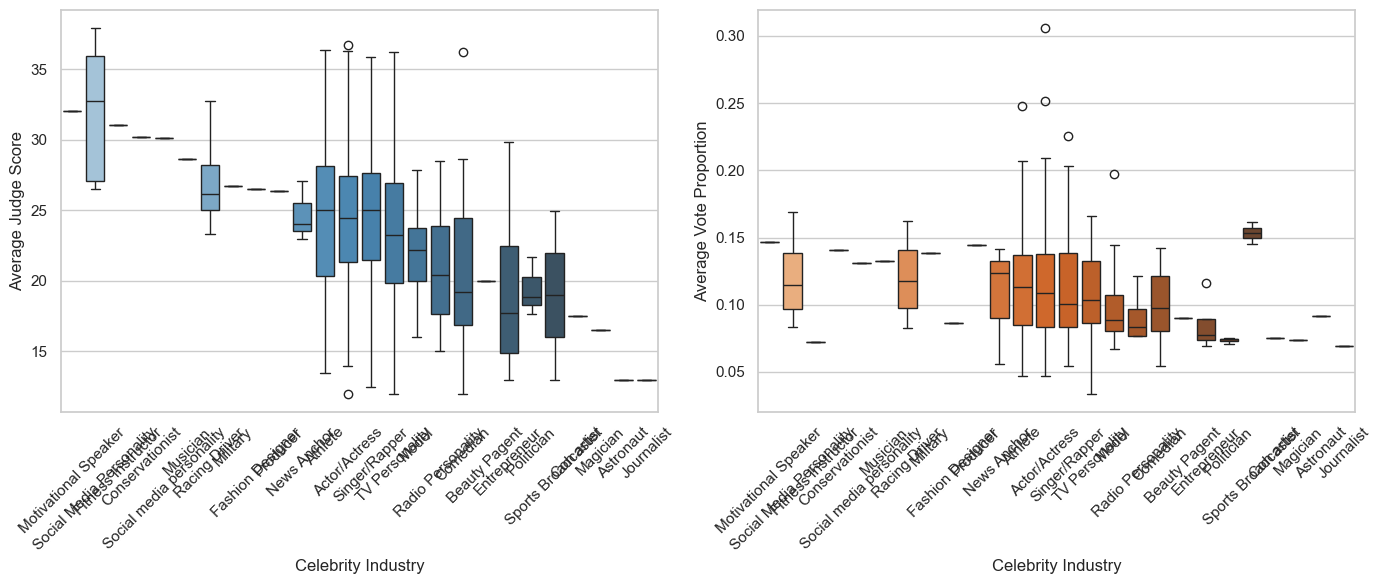

【图1数据特征】
   行业数量: 26
   评委得分最高行业: Motivational Speaker
   评委得分最低行业: Journalist


In [37]:
# 可视化：行业对评委得分和观众投票的影响
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# 图1：行业 vs 评委得分
ax1 = axes[0]
industry_order = industry_performance.index.tolist()
sns.boxplot(data=analysis_df, x='celebrity_industry', y='avg_score', 
            order=industry_order, ax=ax1, palette='Blues_d')
ax1.set_xlabel('Celebrity Industry')
ax1.set_ylabel('Average Judge Score')
ax1.tick_params(axis='x', rotation=45)

# 图2：行业 vs 观众投票
ax2 = axes[1]
sns.boxplot(data=analysis_df, x='celebrity_industry', y='avg_vote_prop', 
            order=industry_order, ax=ax2, palette='Oranges_d')
ax2.set_xlabel('Celebrity Industry')
ax2.set_ylabel('Average Vote Proportion')
ax2.tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.savefig('figures/fig1_industry_impact.pdf', bbox_inches='tight')
plt.show()

print('='*60)
print('【图1数据特征】')
print(f'   行业数量: {len(industry_order)}')
print(f'   评委得分最高行业: {industry_order[0]}')
print(f'   评委得分最低行业: {industry_order[-1]}')
print('='*60)

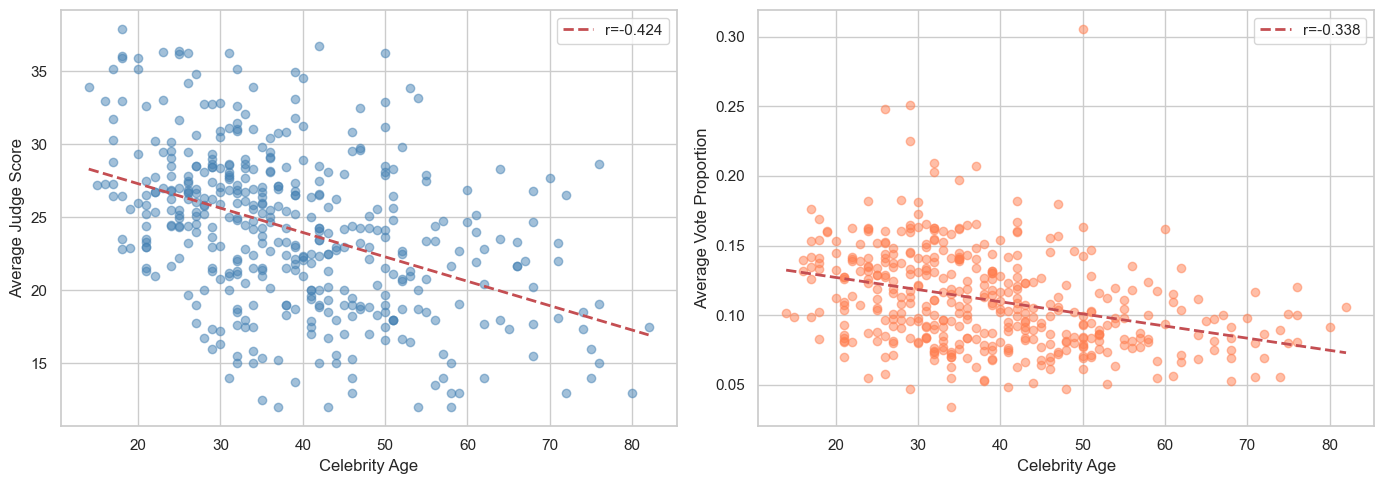

【图2数据特征】
   年龄范围: 14 - 82
   年龄vs评委得分相关系数: -0.424
   年龄vs观众投票相关系数: -0.338


In [38]:
# 可视化：年龄的影响
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# 图1：年龄 vs 评委得分
ax1 = axes[0]
ax1.scatter(analysis_df['celebrity_age'], analysis_df['avg_score'], 
            alpha=0.5, color=COLORS['primary'])
z = np.polyfit(analysis_df['celebrity_age'].dropna(), 
               analysis_df.loc[analysis_df['celebrity_age'].notna(), 'avg_score'], 1)
p = np.poly1d(z)
age_range = np.linspace(analysis_df['celebrity_age'].min(), analysis_df['celebrity_age'].max(), 100)
ax1.plot(age_range, p(age_range), 'r--', linewidth=2, label=f'r={age_score_corr:.3f}')
ax1.set_xlabel('Celebrity Age')
ax1.set_ylabel('Average Judge Score')
ax1.legend()

# 图2：年龄 vs 观众投票
ax2 = axes[1]
ax2.scatter(analysis_df['celebrity_age'], analysis_df['avg_vote_prop'], 
            alpha=0.5, color=COLORS['secondary'])
z2 = np.polyfit(analysis_df['celebrity_age'].dropna(), 
                analysis_df.loc[analysis_df['celebrity_age'].notna(), 'avg_vote_prop'], 1)
p2 = np.poly1d(z2)
ax2.plot(age_range, p2(age_range), 'r--', linewidth=2, label=f'r={age_vote_corr:.3f}')
ax2.set_xlabel('Celebrity Age')
ax2.set_ylabel('Average Vote Proportion')
ax2.legend()

plt.tight_layout()
plt.savefig('figures/fig2_age_impact.pdf', bbox_inches='tight')
plt.show()

print('='*60)
print('【图2数据特征】')
print(f'   年龄范围: {analysis_df["celebrity_age"].min():.0f} - {analysis_df["celebrity_age"].max():.0f}')
print(f'   年龄vs评委得分相关系数: {age_score_corr:.3f}')
print(f'   年龄vs观众投票相关系数: {age_vote_corr:.3f}')
print('='*60)

## 第三部分：回归分析（对比优化前后）

使用多元回归分析各因素的影响程度

**模型对比**:
- **基础模型**: 年龄 + 赛季 + 行业
- **优化模型**: 基础 + 交互效应 + Pro Dancer能力 + Pageviews

In [39]:
# 准备回归数据
# 基础特征
X_baseline = features_df[baseline_features].copy().fillna(0)

# 完整特征
X_full = features_df[all_features].copy().fillna(0)

y_score = features_df['avg_score']
y_vote = features_df['avg_vote_prop']

# 标准化
scaler_baseline = StandardScaler()
scaler_full = StandardScaler()
X_baseline_scaled = scaler_baseline.fit_transform(X_baseline)
X_full_scaled = scaler_full.fit_transform(X_full)

print(f'样本数: {len(X_full)}')
print(f'基础特征数: {X_baseline.shape[1]}')
print(f'优化特征数: {X_full.shape[1]}')

样本数: 421
基础特征数: 29
优化特征数: 38


In [40]:
# 评委得分回归 - 对比基础模型和优化模型
print('='*70)
print('【评委得分回归模型对比】')
print('='*70)

# 基础模型
model_score_baseline = Ridge(alpha=1.0)
score_cv_baseline = cross_val_score(model_score_baseline, X_baseline_scaled, y_score, cv=5, scoring='r2')
print(f'\n📊 基础模型 (年龄+行业):')
print(f'   R² = {score_cv_baseline.mean():.4f} (+/- {score_cv_baseline.std():.4f})')

# 优化模型
model_score_full = Ridge(alpha=1.0)
model_score_full.fit(X_full_scaled, y_score)
score_cv_full = cross_val_score(model_score_full, X_full_scaled, y_score, cv=5, scoring='r2')
print(f'\n📈 优化模型 (+交互效应+Pro Dancer+Pageviews):')
print(f'   R² = {score_cv_full.mean():.4f} (+/- {score_cv_full.std():.4f})')

# 计算提升
r2_improvement_score = (score_cv_full.mean() - score_cv_baseline.mean()) / score_cv_baseline.mean() * 100
print(f'\n🎯 R²提升: {r2_improvement_score:+.1f}%')

# 特征重要性
score_importance = pd.DataFrame({
    'feature': all_features,
    'coefficient': model_score_full.coef_
}).sort_values('coefficient', key=abs, ascending=False)

print('\n特征重要性 (标准化系数) Top 10:')
print(score_importance.head(10).to_string(index=False))

# 保存用于后续绘图
score_cv = score_cv_full

【评委得分回归模型对比】

📊 基础模型 (年龄+行业):
   R² = 0.1280 (+/- 0.0665)

📈 优化模型 (+交互效应+Pro Dancer+Pageviews):
   R² = 0.1319 (+/- 0.0714)

🎯 R²提升: +3.0%

特征重要性 (标准化系数) Top 10:
             feature  coefficient
       age_x_Athlete    -2.606450
              season     2.439681
 age_x_Actor_Actress    -1.734605
 age_x_Singer_Rapper    -1.486396
       avg_placement    -1.353534
    industry_Athlete     1.194351
   industry_Comedian    -1.048617
       log_pageviews    -1.027936
age_x_TV_Personality    -0.807775
      industry_Model    -0.783979


In [41]:
# 观众投票回归 - 对比基础模型和优化模型
print('='*70)
print('【观众投票回归模型对比】')
print('='*70)

# 基础模型
model_vote_baseline = Ridge(alpha=1.0)
vote_cv_baseline = cross_val_score(model_vote_baseline, X_baseline_scaled, y_vote, cv=5, scoring='r2')
print(f'\n📊 基础模型 (年龄+行业):')
print(f'   R² = {vote_cv_baseline.mean():.4f} (+/- {vote_cv_baseline.std():.4f})')

# 优化模型
model_vote_full = Ridge(alpha=1.0)
model_vote_full.fit(X_full_scaled, y_vote)
vote_cv_full = cross_val_score(model_vote_full, X_full_scaled, y_vote, cv=5, scoring='r2')
print(f'\n📈 优化模型 (+交互效应+Pro Dancer+Pageviews):')
print(f'   R² = {vote_cv_full.mean():.4f} (+/- {vote_cv_full.std():.4f})')

# 计算提升
r2_improvement_vote = (vote_cv_full.mean() - vote_cv_baseline.mean()) / max(vote_cv_baseline.mean(), 0.001) * 100
print(f'\n🎯 R²提升: {r2_improvement_vote:+.1f}%')

# 特征重要性
vote_importance = pd.DataFrame({
    'feature': all_features,
    'coefficient': model_vote_full.coef_
}).sort_values('coefficient', key=abs, ascending=False)

print('\n特征重要性 (标准化系数) Top 10:')
print(vote_importance.head(10).to_string(index=False))

# 保存用于后续绘图
vote_cv = vote_cv_full

【观众投票回归模型对比】

📊 基础模型 (年龄+行业):
   R² = 0.0469 (+/- 0.0583)

📈 优化模型 (+交互效应+Pro Dancer+Pageviews):
   R² = 0.0746 (+/- 0.0762)

🎯 R²提升: +59.1%

特征重要性 (标准化系数) Top 10:
             feature  coefficient
              season    -0.015752
       avg_placement    -0.008278
       age_x_Athlete    -0.007601
 age_x_Actor_Actress    -0.006798
age_x_TV_Personality    -0.005549
 age_x_Singer_Rapper    -0.005325
       log_pageviews     0.005287
      industry_Model    -0.005260
       celebrity_age    -0.004469
    industry_Athlete     0.003838


In [42]:
# 使用随机森林获取特征重要性（使用完整特征）
rf_score = RandomForestRegressor(n_estimators=100, random_state=42, max_depth=10)
rf_score.fit(X_full, y_score)

rf_vote = RandomForestRegressor(n_estimators=100, random_state=42, max_depth=10)
rf_vote.fit(X_full, y_vote)

# 特征重要性对比
importance_comparison = pd.DataFrame({
    'feature': all_features,
    'score_importance': rf_score.feature_importances_,
    'vote_importance': rf_vote.feature_importances_
})

importance_comparison['importance_diff'] = importance_comparison['score_importance'] - importance_comparison['vote_importance']
importance_comparison = importance_comparison.sort_values('score_importance', ascending=False)

print('='*70)
print('【随机森林特征重要性对比（优化后模型）】')
print('='*70)
print(importance_comparison.head(15).to_string(index=False))

# 分析Pro Dancer相关特征
print('\n【Pro Dancer能力特征重要性】')
pro_features_importance = importance_comparison[importance_comparison['feature'].isin(pro_dancer_features)]
print(pro_features_importance.to_string(index=False))

# 分析交互效应特征
print('\n【交互效应特征重要性】')
interaction_importance = importance_comparison[importance_comparison['feature'].isin(interaction_features)]
print(interaction_importance.to_string(index=False))

【随机森林特征重要性对比（优化后模型）】
               feature  score_importance  vote_importance  importance_diff
         celebrity_age          0.236593         0.217474         0.019119
                season          0.229104         0.318225        -0.089120
         avg_placement          0.157460         0.136882         0.020578
         log_pageviews          0.089462         0.062850         0.026612
  seasons_participated          0.070561         0.045282         0.025279
   age_x_Actor_Actress          0.031572         0.038119        -0.006547
         age_x_Athlete          0.031554         0.023358         0.008196
         top3_finishes          0.030096         0.045658        -0.015562
  age_x_TV_Personality          0.026830         0.020814         0.006017
                  wins          0.017704         0.022693        -0.004990
     industry_Comedian          0.013442         0.007041         0.006400
   age_x_Singer_Rapper          0.011586         0.021871        -0.010285
    

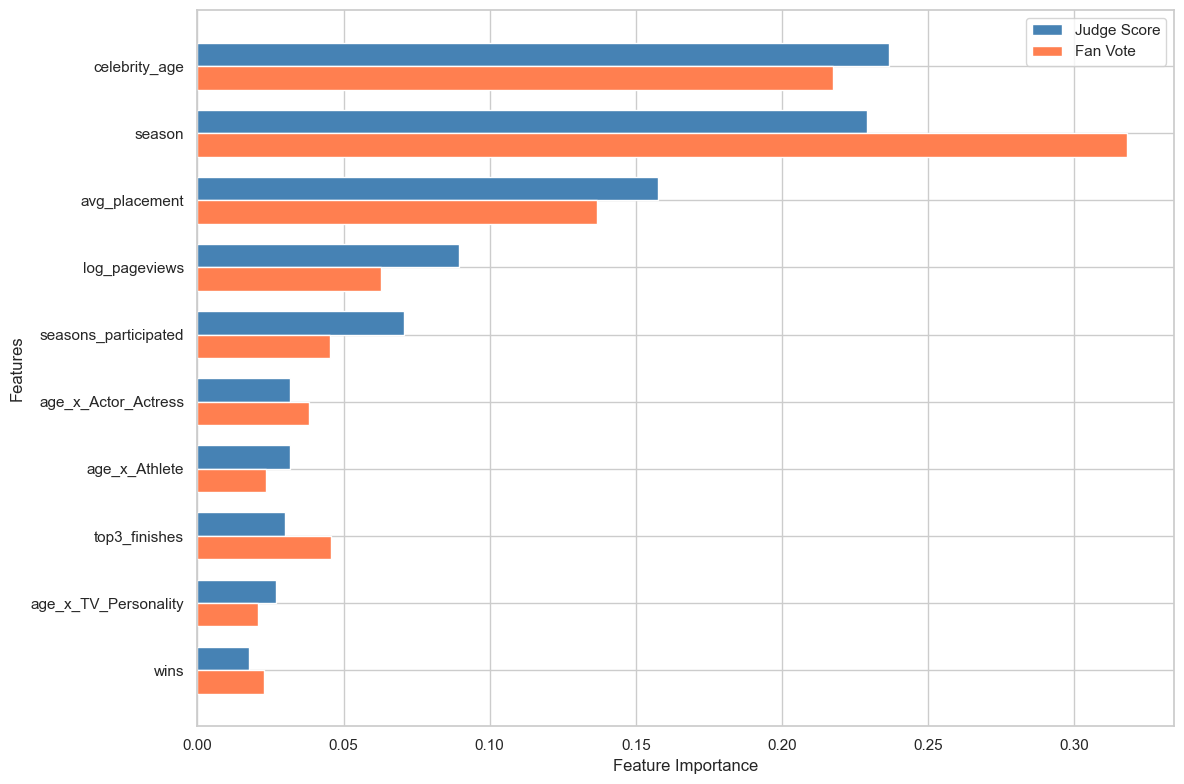

【图3数据特征】
   评委得分R²: 0.132
   观众投票R²: 0.075
   最重要特征: celebrity_age


In [43]:
# 可视化：特征重要性对比
fig, ax = plt.subplots(figsize=(12, 8))

top_features = importance_comparison.head(10)
x = np.arange(len(top_features))
width = 0.35

bars1 = ax.barh(x - width/2, top_features['score_importance'], width,
                label='Judge Score', color=COLORS['primary'])
bars2 = ax.barh(x + width/2, top_features['vote_importance'], width,
                label='Fan Vote', color=COLORS['secondary'])

ax.set_xlabel('Feature Importance')
ax.set_ylabel('Features')
ax.set_yticks(x)
ax.set_yticklabels(top_features['feature'])
ax.legend()
ax.invert_yaxis()

plt.tight_layout()
plt.savefig('figures/fig3_feature_importance.pdf', bbox_inches='tight')
plt.show()

print('='*60)
print('【图3数据特征】')
print(f'   评委得分R²: {score_cv.mean():.3f}')
print(f'   观众投票R²: {vote_cv.mean():.3f}')
print(f'   最重要特征: {top_features.iloc[0]["feature"]}')
print('='*60)

## 第四部分：专业舞者分析

In [44]:
# 按专业舞者分析
pro_performance = analysis_df.groupby('pro_dancer').agg({
    'avg_score': ['mean', 'std', 'count'],
    'avg_vote_prop': ['mean', 'std'],
    'final_rank': 'mean',
    'is_finalist': 'mean'
}).round(3)

pro_performance.columns = ['avg_score_mean', 'avg_score_std', 'count', 
                            'avg_vote_mean', 'avg_vote_std', 'avg_rank', 'finalist_rate']
pro_performance = pro_performance.sort_values('count', ascending=False)

print('='*60)
print('【按专业舞者分析】')
print('='*60)
print(pro_performance.head(15).to_string())

【按专业舞者分析】
                       avg_score_mean  avg_score_std  count  avg_vote_mean  avg_vote_std  avg_rank  finalist_rate
pro_dancer                                                                                                       
Cheryl Burke                   24.297          4.054     25          0.119         0.042     2.250          0.320
Tony Dovolani                  22.453          4.579     21          0.110         0.040     2.333          0.143
Mark Ballas                    27.112          5.031     21          0.125         0.031     2.000          0.476
Valentin Chmerkovskiy          28.684          5.721     19          0.120         0.028     2.111          0.474
Karina Smirnoff                22.565          4.644     18          0.114         0.035     2.000          0.222
Derek Hough                    28.705          3.572     17          0.139         0.017     1.444          0.529
Maksim Chmerkoskiy             25.108          4.090     17          0.121    

In [45]:
# 计算专业舞者效应
# 使用ANOVA检验专业舞者是否显著影响表现
pro_groups_score = [group['avg_score'].values for name, group in analysis_df.groupby('pro_dancer')]
pro_groups_vote = [group['avg_vote_prop'].values for name, group in analysis_df.groupby('pro_dancer')]

# 过滤掉样本太少的组
pro_groups_score = [g for g in pro_groups_score if len(g) >= 3]
pro_groups_vote = [g for g in pro_groups_vote if len(g) >= 3]

f_score, p_score = stats.f_oneway(*pro_groups_score)
f_vote, p_vote = stats.f_oneway(*pro_groups_vote)

print('\n' + '='*60)
print('【专业舞者效应ANOVA检验】')
print('='*60)
print(f'评委得分: F = {f_score:.2f}, p = {p_score:.4f}')
print(f'观众投票: F = {f_vote:.2f}, p = {p_vote:.4f}')

if p_score < 0.05:
    print('结论: 专业舞者对评委得分有显著影响')
else:
    print('结论: 专业舞者对评委得分无显著影响')

if p_vote < 0.05:
    print('结论: 专业舞者对观众投票有显著影响')
else:
    print('结论: 专业舞者对观众投票无显著影响')


【专业舞者效应ANOVA检验】
评委得分: F = 3.62, p = 0.0000
观众投票: F = 1.60, p = 0.0200
结论: 专业舞者对评委得分有显著影响
结论: 专业舞者对观众投票有显著影响


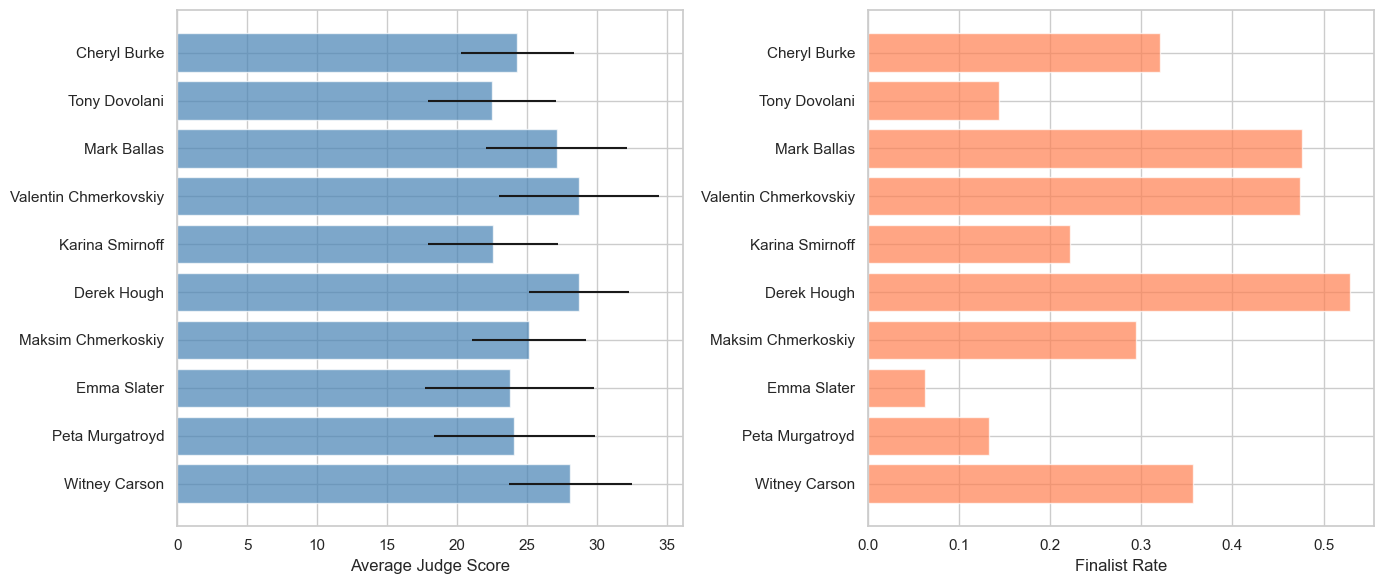

【图4数据特征】
   显示专业舞者数: 10
   平均评委得分最高: Cheryl Burke
   决赛进入率最高: Derek Hough


In [46]:
# 可视化：顶级专业舞者对比
top_pros = pro_performance[pro_performance['count'] >= 5].head(10)

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# 图1：专业舞者 vs 评委得分
ax1 = axes[0]
ax1.barh(range(len(top_pros)), top_pros['avg_score_mean'], 
         xerr=top_pros['avg_score_std'], color=COLORS['primary'], alpha=0.7)
ax1.set_yticks(range(len(top_pros)))
ax1.set_yticklabels(top_pros.index)
ax1.set_xlabel('Average Judge Score')
ax1.invert_yaxis()

# 图2：专业舞者 vs 决赛进入率
ax2 = axes[1]
ax2.barh(range(len(top_pros)), top_pros['finalist_rate'], 
         color=COLORS['secondary'], alpha=0.7)
ax2.set_yticks(range(len(top_pros)))
ax2.set_yticklabels(top_pros.index)
ax2.set_xlabel('Finalist Rate')
ax2.invert_yaxis()

plt.tight_layout()
plt.savefig('figures/fig4_pro_dancer_impact.pdf', bbox_inches='tight')
plt.show()

print('='*60)
print('【图4数据特征】')
print(f'   显示专业舞者数: {len(top_pros)}')
print(f'   平均评委得分最高: {top_pros.index[0]}')
print(f'   决赛进入率最高: {top_pros.sort_values("finalist_rate", ascending=False).index[0]}')
print('='*60)

## 第五部分：综合分析 - 因素对评委vs观众的影响差异

In [47]:
# 计算各因素对评委得分和观众投票影响的差异
print('='*70)
print('【因素影响差异分析】')
print('='*70)

# 1. 年龄的差异
print('\n1. 年龄因素:')
print(f'   对评委得分影响: r = {age_score_corr:.3f}')
print(f'   对观众投票影响: r = {age_vote_corr:.3f}')
if abs(age_score_corr) > abs(age_vote_corr):
    print('   → 年龄对评委得分影响更大')
else:
    print('   → 年龄对观众投票影响更大')

# 2. 行业的差异
print('\n2. 行业因素:')
industry_score_var = analysis_df.groupby('celebrity_industry')['avg_score'].mean().var()
industry_vote_var = analysis_df.groupby('celebrity_industry')['avg_vote_prop'].mean().var()
print(f'   行业间评委得分方差: {industry_score_var:.4f}')
print(f'   行业间观众投票方差: {industry_vote_var:.6f}')

# 3. 专业舞者的差异
print('\n3. 专业舞者因素:')
print(f'   对评委得分: F = {f_score:.2f}, p = {p_score:.4f}')
print(f'   对观众投票: F = {f_vote:.2f}, p = {p_vote:.4f}')

【因素影响差异分析】

1. 年龄因素:
   对评委得分影响: r = -0.424
   对观众投票影响: r = -0.338
   → 年龄对评委得分影响更大

2. 行业因素:
   行业间评委得分方差: 29.8629
   行业间观众投票方差: 0.000670

3. 专业舞者因素:
   对评委得分: F = 3.62, p = 0.0000
   对观众投票: F = 1.60, p = 0.0200


## 第六部分：模型优化效果可视化

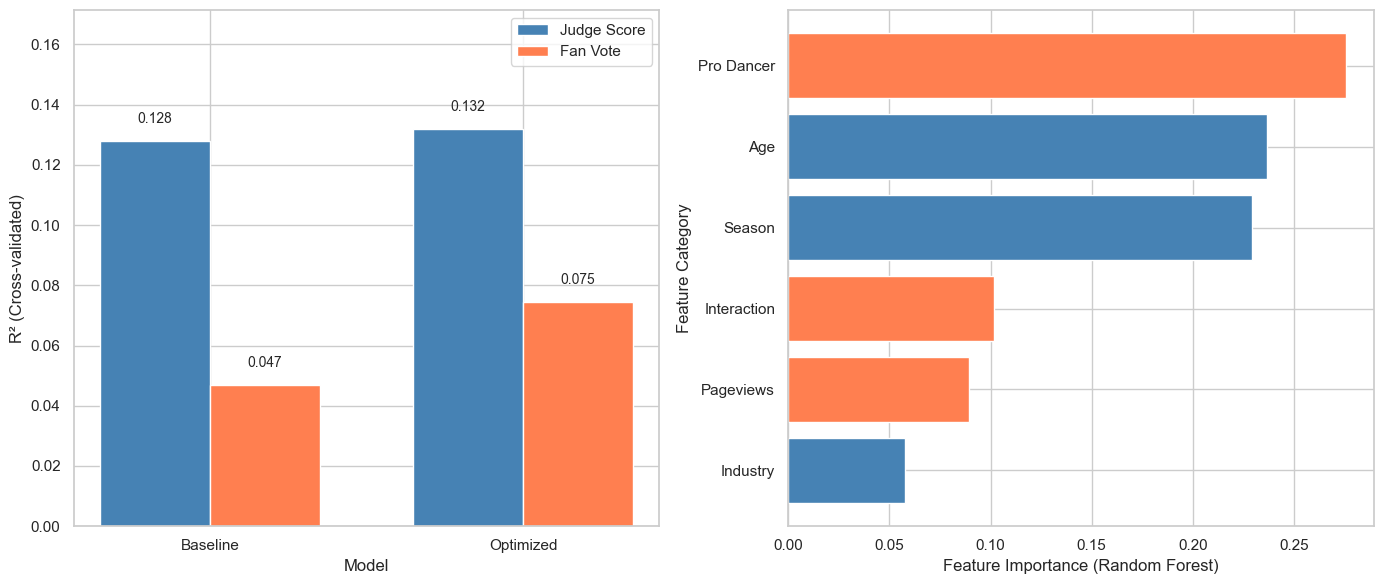

【图5数据特征】
   基础模型 R² (Judge): 0.1280
   优化模型 R² (Judge): 0.1319
   R²提升 (Judge): +3.0%
   基础模型 R² (Vote): 0.0469
   优化模型 R² (Vote): 0.0746


In [48]:
# 模型优化效果可视化
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# 图1：R²对比
ax1 = axes[0]
models = ['Baseline', 'Optimized']
score_r2 = [score_cv_baseline.mean(), score_cv_full.mean()]
vote_r2 = [vote_cv_baseline.mean(), vote_cv_full.mean()]

x = np.arange(len(models))
width = 0.35

bars1 = ax1.bar(x - width/2, score_r2, width, label='Judge Score', color=COLORS['primary'])
bars2 = ax1.bar(x + width/2, vote_r2, width, label='Fan Vote', color=COLORS['secondary'])

ax1.set_xlabel('Model')
ax1.set_ylabel('R² (Cross-validated)')
ax1.set_xticks(x)
ax1.set_xticklabels(models)
ax1.legend()
ax1.set_ylim(0, max(max(score_r2), max(vote_r2)) * 1.3)

# 添加数值标签
for bar, val in zip(bars1, score_r2):
    ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005, f'{val:.3f}', 
             ha='center', va='bottom', fontsize=10)
for bar, val in zip(bars2, vote_r2):
    ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005, f'{val:.3f}', 
             ha='center', va='bottom', fontsize=10)

# 图2：新增特征贡献度
ax2 = axes[1]
# 按特征类别汇总重要性
feature_categories = {
    'Age': ['celebrity_age'],
    'Season': ['season'],
    'Industry': [f for f in all_features if f.startswith('industry_')],
    'Interaction': interaction_features,
    'Pro Dancer': pro_dancer_features,
    'Pageviews': ['log_pageviews'] if HAS_PAGEVIEWS else []
}

category_importance = []
for cat, features in feature_categories.items():
    if features:
        cat_imp = importance_comparison[importance_comparison['feature'].isin(features)]['score_importance'].sum()
        category_importance.append({'category': cat, 'importance': cat_imp})

cat_df = pd.DataFrame(category_importance).sort_values('importance', ascending=True)
colors = ['#4682B4' if cat not in ['Interaction', 'Pro Dancer', 'Pageviews'] else '#FF7F50' 
          for cat in cat_df['category']]
ax2.barh(cat_df['category'], cat_df['importance'], color=colors)
ax2.set_xlabel('Feature Importance (Random Forest)')
ax2.set_ylabel('Feature Category')

plt.tight_layout()
plt.savefig('figures/fig5_model_optimization.pdf', bbox_inches='tight')
plt.show()

print('='*60)
print('【图5数据特征】')
print(f'   基础模型 R² (Judge): {score_cv_baseline.mean():.4f}')
print(f'   优化模型 R² (Judge): {score_cv_full.mean():.4f}')
print(f'   R²提升 (Judge): {r2_improvement_score:+.1f}%')
print(f'   基础模型 R² (Vote): {vote_cv_baseline.mean():.4f}')
print(f'   优化模型 R² (Vote): {vote_cv_full.mean():.4f}')
print('='*60)

In [49]:
# 保存结果
industry_performance.to_csv('industry_analysis.csv')
pro_performance.to_csv('pro_dancer_analysis.csv')
importance_comparison.to_csv('feature_importance.csv', index=False)

# 汇总结果
results_summary = {
    'total_contestants': len(analysis_df),
    'age_score_corr': age_score_corr,
    'age_vote_corr': age_vote_corr,
    'score_model_r2': score_cv.mean(),
    'vote_model_r2': vote_cv.mean(),
    'pro_dancer_score_f': f_score,
    'pro_dancer_score_p': p_score,
    'pro_dancer_vote_f': f_vote,
    'pro_dancer_vote_p': p_vote,
    'top_industry_score': industry_performance.index[0],
    'bottom_industry_score': industry_performance.index[-1]
}

pd.DataFrame([results_summary]).to_csv('results_summary.csv', index=False)
print('\n结果文件已保存')


结果文件已保存


In [50]:
# ============================================================
# 问题三建模结果汇总（优化版）
# ============================================================

print('\n' + '='*70)
print('【问题三建模结果汇总（优化版）】')
print('='*70)

print('\n1. 年龄影响')
print(f'   年龄 vs 评委得分: r = {age_score_corr:.3f}')
print(f'   年龄 vs 观众投票: r = {age_vote_corr:.3f}')
print(f'   年龄范围: {analysis_df["celebrity_age"].min():.0f} - {analysis_df["celebrity_age"].max():.0f}')

print('\n2. 行业影响')
print(f'   评委得分最高: {industry_performance.index[0]} ({industry_performance.iloc[0]["avg_score_mean"]:.2f})')
print(f'   评委得分最低: {industry_performance.index[-1]} ({industry_performance.iloc[-1]["avg_score_mean"]:.2f})')

print('\n3. 专业舞者影响')
print(f'   ANOVA (评委得分): F = {f_score:.2f}, p = {p_score:.4f}')
print(f'   ANOVA (观众投票): F = {f_vote:.2f}, p = {p_vote:.4f}')

print('\n4. 模型优化效果 🎯')
print(f'   评委得分 R² (基础): {score_cv_baseline.mean():.4f}')
print(f'   评委得分 R² (优化): {score_cv_full.mean():.4f} ({r2_improvement_score:+.1f}%)')
print(f'   观众投票 R² (基础): {vote_cv_baseline.mean():.4f}')
print(f'   观众投票 R² (优化): {vote_cv_full.mean():.4f}')

print('\n5. 新增特征贡献')
if len(pro_features_importance) > 0:
    print(f'   Pro Dancer特征总重要性: {pro_features_importance["score_importance"].sum():.4f}')
if len(interaction_importance) > 0:
    print(f'   交互效应特征总重要性: {interaction_importance["score_importance"].sum():.4f}')

print('\n6. 生成的图片')
figures = [
    'fig1_industry_impact.pdf',
    'fig2_age_impact.pdf',
    'fig3_feature_importance.pdf',
    'fig4_pro_dancer_impact.pdf',
    'fig5_model_optimization.pdf'
]
for i, fig_name in enumerate(figures, 1):
    print(f'   图{i}: {fig_name}')

print('\n' + '='*70)
print('✅ 优化完成: 添加了交互效应、Pro Dancer能力、Pageviews特征')
print('='*70)


【问题三建模结果汇总（优化版）】

1. 年龄影响
   年龄 vs 评委得分: r = -0.424
   年龄 vs 观众投票: r = -0.338
   年龄范围: 14 - 82

2. 行业影响
   评委得分最高: Motivational Speaker (32.05)
   评委得分最低: Journalist (13.00)

3. 专业舞者影响
   ANOVA (评委得分): F = 3.62, p = 0.0000
   ANOVA (观众投票): F = 1.60, p = 0.0200

4. 模型优化效果 🎯
   评委得分 R² (基础): 0.1280
   评委得分 R² (优化): 0.1319 (+3.0%)
   观众投票 R² (基础): 0.0469
   观众投票 R² (优化): 0.0746

5. 新增特征贡献
   Pro Dancer特征总重要性: 0.2758
   交互效应特征总重要性: 0.1015

6. 生成的图片
   图1: fig1_industry_impact.pdf
   图2: fig2_age_impact.pdf
   图3: fig3_feature_importance.pdf
   图4: fig4_pro_dancer_impact.pdf
   图5: fig5_model_optimization.pdf

✅ 优化完成: 添加了交互效应、Pro Dancer能力、Pageviews特征
